# IMOS Global Reef Fish Abundance & Biomass EDA

This notebook explores the IMOS National Reef Monitoring Network Sub-Facility dataset.

In [2]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

## Unformatted Column Descriptions
- The original dataset was prepended with 71 rows of column descriptions. These have been removed from the dataset and stored in `column_descriptions` for reference:

In [3]:
coldesc_df = pd.read_csv('imos_coldescs.csv', sep='\t', dtype=str)
coldesc_df.columns = [col.lstrip('# ').strip() for col in coldesc_df.columns]
if coldesc_df.columns.size > 0:
    first_col = coldesc_df.columns[0]
    coldesc_df[first_col] = coldesc_df[first_col].astype(str).str.lstrip('#').str.strip()
coldesc_df = coldesc_df.fillna('')
coldesc_df

,data_column_name,cf_standard_name,long_name,imos_vocabulary_name,unit_name,unit_short_name
0,abundance,number_concentration_of_biological_taxon_in_se...,taxonomic level abundance,Abundance of biota,,
1,area,,state/territory where the survey was conducted,,,
2,avg_rugosity,,average roughness of the floor surface,,,
3,biomass,,estimated biomass,,Grams,g
4,block,,number of the block,,,
5,category,,sub-class of the annotation schema,,,
6,class,biological_taxon_name,identification of the biotic elements to the s...,Biotic taxonomic identification,,
7,common_class_name,,common name of the taxonomic rank,,,
8,common_family_name,,common name of the taxonomic rank,,,
9,common_name,,common name of the taxonomic rank,,,


In [4]:
DATA_PATH = Path(os.getenv(
    'IMOS_DATASET_PATH',
    # 'IMOS_-_National_Reef_Monitoring_Network_Sub-Facility_-_Global_reef_fish_abundance_and_biomass.csv'
    'IMOS_-_National_Reef_Monitoring_Network_Sub-Facility_-_Global_reef_fish_abundance_and_biomass_complete_trimmed.csv'
))
DATA_PATH


WindowsPath('IMOS_-_National_Reef_Monitoring_Network_Sub-Facility_-_Global_reef_fish_abundance_and_biomass_complete_trimmed.csv')

In [5]:
df = pd.read_csv(DATA_PATH, dtype=str, na_values=[''], engine='python', on_bad_lines='warn', skipinitialspace=True)
df.columns = [col.lstrip('# ').strip() for col in df.columns]
for col in df.columns:
    df[col] = df[col].str.strip()
# robustly handle missing/alternate column names
candidates = [col for col in df.columns if ('data' in col.lower() and 'column' in col.lower() and 'name' in col.lower())]
if candidates:
    if candidates[0] != 'data_column_name':
        df = df.rename(columns={candidates[0]: 'data_column_name'})
    df['data_column_name'] = df['data_column_name'].astype(str).str.lstrip('#').str.strip()
else:
    df['data_column_name'] = np.nan
df.head()


,FID,survey_id,country,area,ecoregion,realm,location,site_code,site_name,latitude,longitude,survey_date,depth,program,visibility,hour,survey_latitude,survey_longitude,method,block,phylum,class,order,family,species_name,reporting_name,size_class,total,biomass,geom,data_column_name
0,ep_m1_public_data.fid--43bec24c_19e67c26e25_-3717,1003264,United States,California,Northern California,Temperate Northern Pacific,Channel Islands,USWC9,Hare Rock San Miguel,34.06,-120.36,2010-09-14,7.1,RLS,NaN,NaN,NaN,NaN,1,1,Chordata,Actinopterygii,Perciformes,Gobiidae,Rhinogobiops nicholsii,Rhinogobiops nicholsii,5,4,8.9985,POINT (-120.36000061035156 34.060001373291016),NaN
1,ep_m1_public_data.fid--43bec24c_19e67c26e25_-3716,1003264,United States,California,Northern California,Temperate Northern Pacific,Channel Islands,USWC9,Hare Rock San Miguel,34.06,-120.36,2010-09-14,7.1,RLS,NaN,NaN,NaN,NaN,1,1,Chordata,Actinopterygii,Perciformes,Gobiidae,Rhinogobiops nicholsii,Rhinogobiops nicholsii,7.5,5,38.1167,POINT (-120.36000061035156 34.060001373291016),NaN
2,ep_m1_public_data.fid--43bec24c_19e67c26e25_-3715,1003264,United States,California,Northern California,Temperate Northern Pacific,Channel Islands,USWC9,Hare Rock San Miguel,34.06,-120.36,2010-09-14,7.1,RLS,NaN,NaN,NaN,NaN,1,1,Chordata,Actinopterygii,Scorpaeniformes,Cottidae,Orthonopias triacis,Orthonopias triacis,5,2,4.8475,POINT (-120.36000061035156 34.060001373291016),NaN
3,ep_m1_public_data.fid--43bec24c_19e67c26e25_-3714,1003264,United States,California,Northern California,Temperate Northern Pacific,Channel Islands,USWC9,Hare Rock San Miguel,34.06,-120.36,2010-09-14,7.1,RLS,NaN,NaN,NaN,NaN,1,1,Chordata,Actinopterygii,Scorpaeniformes,Cottidae,Scorpaenichthys marmoratus,Scorpaenichthys marmoratus,50,2,1198.903,POINT (-120.36000061035156 34.060001373291016),NaN
4,ep_m1_public_data.fid--43bec24c_19e67c26e25_-3713,1003264,United States,California,Northern California,Temperate Northern Pacific,Channel Islands,USWC9,Hare Rock San Miguel,34.06,-120.36,2010-09-14,7.1,RLS,NaN,NaN,NaN,NaN,1,1,Chordata,Actinopterygii,Scorpaeniformes,Hexagrammidae,Ophiodon elongatus,Ophiodon elongatus,50,1,599.4515,POINT (-120.36000061035156 34.060001373291016),NaN


In [6]:
df

,FID,survey_id,country,area,ecoregion,realm,location,site_code,site_name,latitude,longitude,survey_date,depth,program,visibility,hour,survey_latitude,survey_longitude,method,block,phylum,class,order,family,species_name,reporting_name,size_class,total,biomass,geom,data_column_name
0,ep_m1_public_data.fid--43bec24c_19e67c26e25_-3717,1003264,United States,California,Northern California,Temperate Northern Pacific,Channel Islands,USWC9,Hare Rock San Miguel,34.06,-120.36,2010-09-14,7.1,RLS,NaN,NaN,NaN,NaN,1,1,Chordata,Actinopterygii,Perciformes,Gobiidae,Rhinogobiops nicholsii,Rhinogobiops nicholsii,5,4,8.9985,POINT (-120.36000061035156 34.060001373291016),NaN
1,ep_m1_public_data.fid--43bec24c_19e67c26e25_-3716,1003264,United States,California,Northern California,Temperate Northern Pacific,Channel Islands,USWC9,Hare Rock San Miguel,34.06,-120.36,2010-09-14,7.1,RLS,NaN,NaN,NaN,NaN,1,1,Chordata,Actinopterygii,Perciformes,Gobiidae,Rhinogobiops nicholsii,Rhinogobiops nicholsii,7.5,5,38.1167,POINT (-120.36000061035156 34.060001373291016),NaN
2,ep_m1_public_data.fid--43bec24c_19e67c26e25_-3715,1003264,United States,California,Northern California,Temperate Northern Pacific,Channel Islands,USWC9,Hare Rock San Miguel,34.06,-120.36,2010-09-14,7.1,RLS,NaN,NaN,NaN,NaN,1,1,Chordata,Actinopterygii,Scorpaeniformes,Cottidae,Orthonopias triacis,Orthonopias triacis,5,2,4.8475,POINT (-120.36000061035156 34.060001373291016),NaN
3,ep_m1_public_data.fid--43bec24c_19e67c26e25_-3714,1003264,United States,California,Northern California,Temperate Northern Pacific,Channel Islands,USWC9,Hare Rock San Miguel,34.06,-120.36,2010-09-14,7.1,RLS,NaN,NaN,NaN,NaN,1,1,Chordata,Actinopterygii,Scorpaeniformes,Cottidae,Scorpaenichthys marmoratus,Scorpaenichthys marmoratus,50,2,1198.903,POINT (-120.36000061035156 34.060001373291016),NaN
4,ep_m1_public_data.fid--43bec24c_19e67c26e25_-3713,1003264,United States,California,Northern California,Temperate Northern Pacific,Channel Islands,USWC9,Hare Rock San Miguel,34.06,-120.36,2010-09-14,7.1,RLS,NaN,NaN,NaN,NaN,1,1,Chordata,Actinopterygii,Scorpaeniformes,Hexagrammidae,Ophiodon elongatus,Ophiodon elongatus,50,1,599.4515,POINT (-120.36000061035156 34.060001373291016),NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1809451,ep_m1_public_data.fid--43bec24c_19e67d5dcc8_655b,923406500,Australia,Queensland,Torres Strait Northern Great Barrier Reef,Central Indo-Pacific,Torres Strait,TS35,Seven Reefs Dropoff,-10.29,143.71,2025-12-13,4,RLS,18,12:00:00,NaN,NaN,1,1,Chordata,Actinopterygii,Perciformes,Pomacentridae,Dascyllus trimaculatus,Dascyllus trimaculatus,10,5,251.7242,POINT (143.7100067138672 -10.289999961853027),NaN
1809452,ep_m1_public_data.fid--43bec24c_19e67d5dcc8_655c,923406500,Australia,Queensland,Torres Strait Northern Great Barrier Reef,Central Indo-Pacific,Torres Strait,TS35,Seven Reefs Dropoff,-10.29,143.71,2025-12-13,4,RLS,18,12:00:00,NaN,NaN,1,1,Chordata,Actinopterygii,Perciformes,Pomacentridae,Pomacentrus brachialis,Pomacentrus brachialis,2.5,95,59.1516,POINT (143.7100067138672 -10.289999961853027),NaN
1809453,ep_m1_public_data.fid--43bec24c_19e67d5dcc8_655d,923406513,Australia,Northern Territory,Arnhem Coast to Gulf of Carpenteria,Central Indo-Pacific,Arafura,NT67,Hogmany Shoal South,-10.98,133.16,2025-12-04,14,RLS,16,13:20:00,NaN,NaN,1,2,Chordata,Actinopterygii,Perciformes,Chaetodontidae,Chaetodon aureofasciatus,Chaetodon aureofasciatus,12.5,3,231.9638,POINT (133.16000366210938 -10.979999542236328),NaN
1809454,ep_m1_public_data.fid--43bec24c_19e67d5dcc8_655e,923406513,Australia,Northern Territory,Arnhem Coast to Gulf of Carpenteria,Central Indo-Pacific,Arafura,NT67,Hogmany Shoal South,-10.98,133.16,2025-12-04,14,RLS,16,13:20:00,NaN,NaN,1,2,Chordata,Actinopterygii,Perciformes,Chaetodontidae,Chelmon marginalis,Chelmon marginalis,15,4,537.631,POINT (133.16000366210938 -10.979999542236328),NaN


In [7]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
FID,1809456,1809456,ep_m1_public_data.fid--43bec24c_19e67c26e25_-3717,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
survey_id,1809456,33806,912347793,495,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,1809234,59,Australia,1454568,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area,1809456,153,New South Wales,409634,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ecoregion,1809456,104,Cape Howe,266616,NaN,NaN,NaN,NaN,NaN,NaN,NaN
realm,1809456,12,Temperate Australasia,810309,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,1809456,221,Jervis Bay,129975,NaN,NaN,NaN,NaN,NaN,NaN,NaN
site_code,1809456,4787,PS17,13384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
site_name,1809456,4761,Fly Point Nelson Bay,13384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,1809456,2172,-32.71,38225,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Unique Species

In [8]:
preferred_species_cols = ['species_name', 'reporting_name', 'species', 'species_scientific_name']
species_col = next((c for c in preferred_species_cols if c in df.columns), None)
if species_col is None:
    fallback = [c for c in df.columns if ('species' in c.lower() or 'taxon' in c.lower() or 'scientific' in c.lower())]
    species_col = fallback[0] if fallback else None

preferred_location_cols = ['site_name', 'site_code', 'location', 'survey_id', 'site', 'reef_name', 'reef']
location_col = next((c for c in preferred_location_cols if c in df.columns), None)
if location_col is None:
    fallback = [c for c in df.columns if ('location' in c.lower() or 'site' in c.lower() or 'reef' in c.lower())]
    location_col = fallback[0] if fallback else None

preferred_date_cols = ['date', 'survey_date', 'sample_date', 'event_date', 'obs_date', 'datetime', 'date_time', 'start_date', 'end_date']
date_col = next((c for c in preferred_date_cols if c in df.columns), None)
if date_col is None:
    fallback = [c for c in df.columns if ('date' in c.lower() or 'time' in c.lower())]
    date_col = fallback[0] if fallback else None

if species_col is None:
    print('No species column found.')
else:
    print(f'Unique species ({species_col}): {df[species_col].nunique(dropna=True)}')

if location_col is None:
    print('No reef/location column found.')
else:
    print(f'Unique reefs/locations ({location_col}): {df[location_col].nunique(dropna=True)}')

if date_col is None:
    print('No date column found.')
else:
    dates = pd.to_datetime(df[date_col], errors='coerce')
    first_date = dates.min()
    last_date = dates.max()
    if pd.isna(first_date) or pd.isna(last_date):
        print(f'Date column found ({date_col}) but no parseable dates.')
    else:
        span = last_date - first_date
        print(f'Date column: {date_col}')
        print(f'First date: {first_date}')
        print(f'Last date: {last_date}')
        print(f'Time span: {span}')

Unique species (species_name): 3465
Unique reefs/locations (site_name): 4761
Date column: survey_date
First date: 1992-03-10 00:00:00
Last date: 2026-05-14 00:00:00
Time span: 12483 days 00:00:00


## Per Year Reports

Reports per year:
survey_date
1992      9434
1993      5716
1994      6734
1995      3582
1996      6726
1997      9036
1998      2922
1999     11346
2000     17140
2001     16105
2002      8665
2003      8619
2004     16186
2005     22415
2006     42033
2007     37976
2008     53216
2009     81109
2010     86604
2011     78951
2012    105438
2013    109245
2014     52347
2015    123014
2016    104671
2017     97132
2018    108017
2019     70994
2020     63437
2021     76957
2022     66447
2023    107323
2024    117009
2025     71924
2026     10986
Name: count, dtype: int64


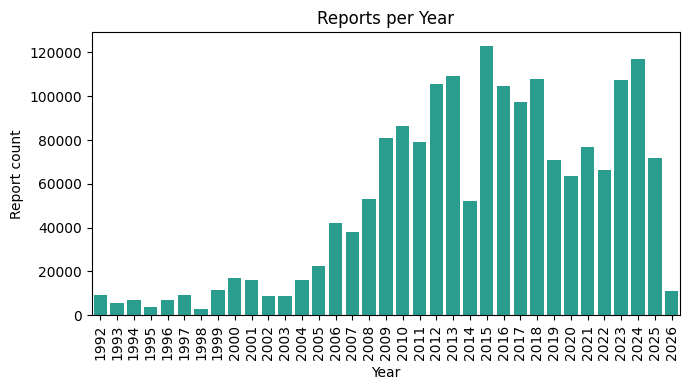

In [9]:
dates = pd.to_datetime(df[date_col], errors='coerce')
year_counts = dates.dt.year.value_counts(dropna=True).sort_index()
start_year = 1992
end_year = 2026
year_counts = year_counts.reindex(range(start_year, end_year + 1), fill_value=0)
print('Reports per year:')
print(year_counts)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(year_counts.index.astype(int), year_counts.values, color='#2a9d8f')
ax.set_xlabel('Year')
ax.set_ylabel('Report count')
ax.set_title('Reports per Year')
ax.set_xticks(range(start_year, end_year + 1))
ax.set_xlim(start_year - 0.5, end_year + 0.5)
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()

Reports per year (blacktip reef shark only):
survey_date
1992     0
1993     0
1994     0
1995     0
1996     0
1997     0
1998     0
1999     0
2000     0
2001     0
2002     0
2003     0
2004     0
2005     0
2006     0
2007     0
2008     0
2009    14
2010     0
2011     0
2012    21
2013     2
2014     7
2015     2
2016     0
2017     0
2018     3
2019     2
2020     0
2021     4
2022     3
2023     1
2024     1
2025     2
2026     0
Name: count, dtype: int64


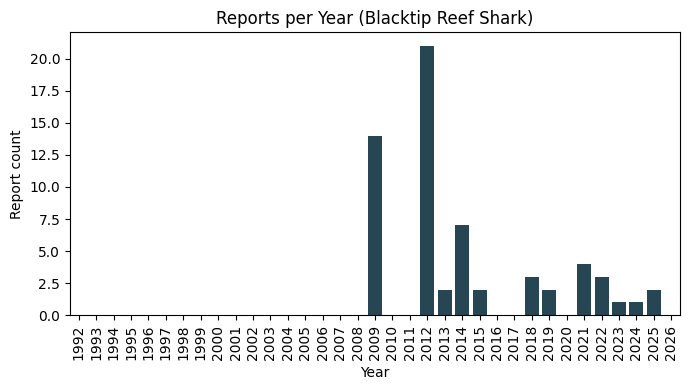

In [10]:
if date_col is None:
    print('No date column found; cannot aggregate by year.')
else:
    blacktip_scientific = 'Carcharhinus melanopterus'
    blacktip_common = 'blacktip reef shark'

    name_cols = [col for col in ['species_name', 'reporting_name'] if col in df.columns]
    if not name_cols:
        print('No species name columns found; cannot filter by blacktip reef shark.')
    else:
        bt_mask = pd.Series(False, index=df.index)
        for col in name_cols:
            bt_mask |= df[col].str.contains(blacktip_scientific, case=False, na=False)
            bt_mask |= df[col].str.contains(blacktip_common, case=False, na=False)

        dates = pd.to_datetime(df.loc[bt_mask, date_col], errors='coerce')
        year_counts = dates.dt.year.value_counts(dropna=True).sort_index()
        start_year = 1992
        end_year = 2026
        year_counts = year_counts.reindex(range(start_year, end_year + 1), fill_value=0)
        print('Reports per year (blacktip reef shark only):')
        print(year_counts)

        fig, ax = plt.subplots(figsize=(7, 4))
        ax.bar(year_counts.index.astype(int), year_counts.values, color='#264653')
        ax.set_xlabel('Year')
        ax.set_ylabel('Report count')
        ax.set_title('Reports per Year (Blacktip Reef Shark)')
        ax.set_xticks(range(start_year, end_year + 1))
        ax.set_xlim(start_year - 0.5, end_year + 0.5)
        ax.tick_params(axis='x', rotation=90)
        plt.tight_layout()

## Blacktip reef shark coverage
- Some datasets only contained bony fish and no elasmobrancs :(
- The imos dataset does contain them though

Location col: site_name
locations with BRS: 39 / 4761 (0.008)
Surveys with BRS sightings (survey_id): 43
BRS abundance per survey (survey_id) (total):
min     1.000000
25%     1.000000
50%     1.000000
mean    1.674419
75%     2.000000
max     7.000000
Name: total_num, dtype: float64
BRS biomass per location (total):
min        510.977900
25%       8271.583000
50%      11033.091000
mean     18176.825941
75%      19304.674000
max     120298.977000
Name: biomass_num, dtype: float64


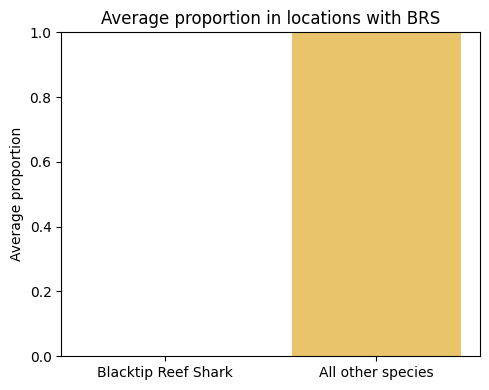

In [11]:
blacktip_scientific = 'Carcharhinus melanopterus'
blacktip_common = 'blacktip reef shark'

name_cols = [col for col in ['species_name', 'reporting_name'] if col in df.columns]
bt_mask = pd.Series(False, index=df.index)
for col in name_cols:
    bt_mask |= df[col].str.contains(blacktip_scientific, case=False, na=False)
    bt_mask |= df[col].str.contains(blacktip_common, case=False, na=False)

df['total_num'] = pd.to_numeric(df['total'], errors='coerce') if 'total' in df.columns else np.nan
df['biomass_num'] = pd.to_numeric(df['biomass'], errors='coerce') if 'biomass' in df.columns else np.nan

preferred_location_cols = ['site_name', 'site_code', 'location', 'survey_id', 'site']
location_col = next((c for c in preferred_location_cols if c in df.columns), None)
if location_col is None:
    fallback = [c for c in df.columns if 'location' in c.lower() or 'site' in c.lower()]
    location_col = fallback[0] if fallback else None

if location_col is None:
    print('No location column found; cannot summarise by location.')
else:
    locations_total = df[location_col].dropna().unique()
    locations_with_blacktip = df.loc[bt_mask, location_col].dropna().unique()
    count_locations_blacktip = len(locations_with_blacktip)
    total_locations = len(locations_total)
    prop_locations_blacktip = (count_locations_blacktip / total_locations) if total_locations else np.nan

    df_kept = df[df[location_col].isin(locations_with_blacktip)]

    preferred_survey_cols = ['survey_id', 'sample_id', 'event_id', 'transect_id', 'replicate_id']
    survey_col = next((c for c in preferred_survey_cols if c in df.columns), None)
    if survey_col is None:
        fallback = [c for c in df.columns if 'survey' in c.lower() or 'transect' in c.lower() or 'event' in c.lower()]
        survey_col = fallback[0] if fallback else None

    if survey_col is None:
        if date_col is not None:
            survey_key = [location_col, date_col]
            survey_label = f'{location_col}+{date_col}'
        else:
            survey_key = [location_col]
            survey_label = location_col
    else:
        survey_key = [survey_col]
        survey_label = survey_col

    brs_survey_count = df.loc[bt_mask, survey_key].dropna().drop_duplicates().shape[0]

    blacktip_abundance = df.loc[bt_mask].groupby(survey_key)['total_num'].sum(min_count=1)
    bt_desc = blacktip_abundance.describe(percentiles=[0.25, 0.5, 0.75])
    blacktip_biomass = df.loc[bt_mask].groupby(location_col)['biomass_num'].sum(min_count=1)
    bt_biomass_desc = blacktip_biomass.describe(percentiles=[0.25, 0.5, 0.75])

    print(f'Location col: {location_col}')
    print(f'locations with BRS: {count_locations_blacktip} / {total_locations} ({prop_locations_blacktip:.3f})')
    print(f'Surveys with BRS sightings ({survey_label}): {brs_survey_count}')
    print(f'BRS abundance per survey ({survey_label}) (total):')
    print(bt_desc[['min', '25%', '50%', 'mean', '75%', 'max']])
    if not bt_biomass_desc.empty:
        print('BRS biomass per location (total):')
        print(bt_biomass_desc[['min', '25%', '50%', 'mean', '75%', 'max']])

    total_per_location = df_kept.groupby(location_col)['total_num'].sum(min_count=1)
    blacktip_abundance = blacktip_abundance.reindex(total_per_location.index, fill_value=0)
    proportions = blacktip_abundance / total_per_location
    avg_prop = proportions.mean()
    avg_other = 1 - avg_prop

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.bar(['Blacktip Reef Shark', 'All other species'], [avg_prop, avg_other], color=['#2a9d8f', '#e9c46a'])
    ax.set_ylim(0, 1)
    ax.set_ylabel('Average proportion')
    ax.set_title('Average proportion in locations with BRS')
    plt.tight_layout()

## Mapped locations of BRS observations

In [12]:
GEN_MAP = False  # set this to false to SKIP running the google api query

Blacktip locations (1):
          site_name  survey_latitude  survey_longitude
Tahanea Outside NE2           -16.86           -144.66
GEN_MAP=False; skipping geocoding API calls.


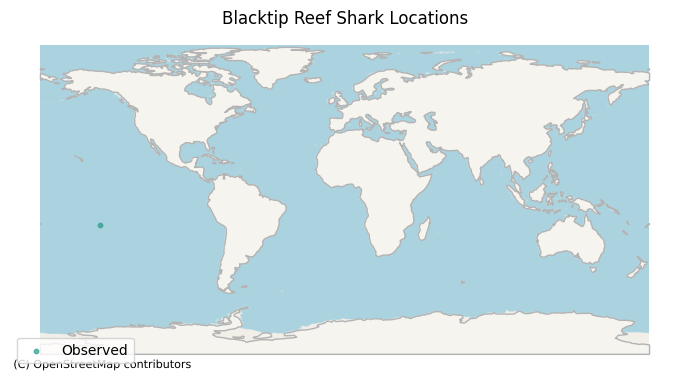

In [13]:
import json
import time
from urllib.parse import urlencode
from urllib.request import Request, urlopen
import geopandas as gpd
import contextily as ctx
import geodatasets

blacktip_scientific = 'Carcharhinus melanopterus'
blacktip_common = 'blacktip reef shark'
name_cols = [col for col in ['species_name', 'reporting_name'] if col in df.columns]
if not name_cols:
    print('No species name columns found; cannot filter by blacktip reef shark.')
else:
    bt_mask = pd.Series(False, index=df.index)
    for col in name_cols:
        bt_mask |= df[col].str.contains(blacktip_scientific, case=False, na=False)
        bt_mask |= df[col].str.contains(blacktip_common, case=False, na=False)

    preferred_lat_cols = ['survey_latitude', 'latitude', 'lat', 'dec_lat', 'decimal_latitude']
    preferred_lon_cols = ['survey_longitude', 'longitude', 'lon', 'dec_lon', 'decimal_longitude']
    preferred_location_cols = ['site_name', 'site_code', 'location', 'survey_id', 'site', 'reef_name', 'reef']
    lat_col = next((c for c in preferred_lat_cols if c in df.columns), None)
    lon_col = next((c for c in preferred_lon_cols if c in df.columns), None)

    location_col = next((c for c in preferred_location_cols if c in df.columns), None)

    if lat_col is None or lon_col is None:
        print('No latitude/longitude columns found; cannot plot map.')
        print('Columns checked (lat):', preferred_lat_cols)
        print('Columns checked (lon):', preferred_lon_cols)
    else:
        keep_cols = [lat_col, lon_col] + ([location_col] if location_col else [])
        coords = df.loc[bt_mask, keep_cols].copy()
        coords[lat_col] = pd.to_numeric(coords[lat_col], errors='coerce')
        coords[lon_col] = pd.to_numeric(coords[lon_col], errors='coerce')
        coords = coords.dropna(subset=[lat_col, lon_col]).drop_duplicates()

        if coords.empty:
            print('No valid coordinates for blacktip reef sharks.')
        else:
            if location_col:
                locations = coords[[location_col, lat_col, lon_col]].drop_duplicates().sort_values([location_col, lat_col, lon_col])
                print(f'Blacktip locations ({len(locations)}):')
                print(locations.to_string(index=False))
            else:
                print('Blacktip coordinates (no location column available):')
                print(coords[[lat_col, lon_col]].drop_duplicates().sort_values([lat_col, lon_col]).to_string(index=False))

            geocoded_df = None
            if location_col and GEN_MAP:
                bt_loc_coords = df.loc[bt_mask, [location_col, lat_col, lon_col]].copy()
                bt_loc_coords[location_col] = bt_loc_coords[location_col].astype(str).str.strip()
                bt_loc_coords[lat_col] = pd.to_numeric(bt_loc_coords[lat_col], errors='coerce')
                bt_loc_coords[lon_col] = pd.to_numeric(bt_loc_coords[lon_col], errors='coerce')
                has_coords = bt_loc_coords[lat_col].notna() & bt_loc_coords[lon_col].notna()

                all_locations = bt_loc_coords[location_col].dropna().unique()
                locations_with_coords = bt_loc_coords.loc[has_coords, location_col].dropna().unique()
                missing_locations = sorted(set(all_locations) - set(locations_with_coords))

                if missing_locations:
                    contact_email = 'aarontan834@gmail.com'
                    user_agent = f'imos-eda-geocoder/1.0 ({contact_email})'
                    base_url = 'https://nominatim.openstreetmap.org/search'
                    results = []

                    def geocode_one(query):
                        params = {
                            'q': query,
                            'format': 'json',
                            'limit': 1,
                            'email': contact_email,
                            'addressdetails': 1,
                        }
                        url = f'{base_url}?{urlencode(params)}'
                        req = Request(url, headers={'User-Agent': user_agent})
                        with urlopen(req, timeout=20) as resp:
                            return json.loads(resp.read().decode('utf-8'))

                    for name in missing_locations:
                        attempts = [
                            name,
                        ]
                        payload = []
                        error_msg = ''
                        for query in attempts:
                            try:
                                payload = geocode_one(query)
                                if payload:
                                    break
                            except Exception as exc:
                                error_msg = str(exc)
                                payload = []
                            time.sleep(1)

                        if payload:
                            results.append({
                                'location_name': name,
                                'lat': float(payload[0]['lat']),
                                'lon': float(payload[0]['lon']),
                                'display_name': payload[0].get('display_name', ''),
                            })
                        else:
                            results.append({
                                'location_name': name,
                                'lat': None,
                                'lon': None,
                                'display_name': f'NO MATCH {error_msg}'.strip(),
                            })

                    geocoded_df = pd.DataFrame(results)
                    print('Geocoding results (approximate):')
                    print(geocoded_df.to_string(index=False))
            elif location_col and not GEN_MAP:
                print('GEN_MAP=False; skipping geocoding API calls.')

            gdf = gpd.GeoDataFrame(
                coords,
                geometry=gpd.points_from_xy(coords[lon_col], coords[lat_col]),
                crs='EPSG:4326'
            )

            world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
            ax = world.plot(figsize=(7, 5), color='#f6f4ef', edgecolor='#b3b3b3')
            gdf.plot(ax=ax, color='#2a9d8f', markersize=10, alpha=0.7, label='Observed')

            if geocoded_df is not None:
                approx = geocoded_df.dropna(subset=['lat', 'lon'])
                if not approx.empty:
                    approx_gdf = gpd.GeoDataFrame(
                        approx,
                        geometry=gpd.points_from_xy(approx['lon'], approx['lat']),
                        crs='EPSG:4326'
                    )
                    approx_gdf.plot(ax=ax, color='#e76f51', markersize=10, alpha=0.7, label='Geocoded (approx)')

            try:
                ctx.add_basemap(ax, crs=gdf.crs, source=ctx.providers.OpenStreetMap.Mapnik)
            except Exception as exc:
                print(f'Basemap skipped: {exc}')

            ax.set_title('Blacktip Reef Shark Locations')
            ax.set_axis_off()
            ax.legend(loc='lower left')
            plt.tight_layout()

## Missing Values

- Columns with missing values, 1.0 is completely missing:

In [14]:
missingness = df.isna().mean().sort_values(ascending=False)
completely_missing = missingness[missingness == 1.0]
some_missing = missingness[(missingness > 0.0) & (missingness < 1.0)]
non_missing = missingness[missingness == 0.0]

print(f'Completely missing: {len(completely_missing)}')
print(completely_missing.index.tolist())
print(f'Some missing: {len(some_missing)}')
print(some_missing.index.tolist())
print(f'Fully populated: {len(non_missing)}')
print(non_missing.index.tolist())

Completely missing: 1
['data_column_name']
Some missing: 10
['survey_longitude', 'survey_latitude', 'hour', 'visibility', 'biomass_num', 'biomass', 'family', 'order', 'country', 'reporting_name']
Fully populated: 22
['FID', 'site_name', 'realm', 'survey_id', 'area', 'ecoregion', 'program', 'longitude', 'survey_date', 'depth', 'latitude', 'location', 'site_code', 'method', 'species_name', 'class', 'block', 'phylum', 'total', 'size_class', 'geom', 'total_num']


## Survey Date Sanity Check
- From the below output, all survey entries in a single survey share the exact same timestamp, which is expected.
- This is important to make the assumption that 1 survey = 1 timestamp.

In [15]:
# Check whether surveys share identical timestamps or need another key
preferred_survey_cols = ['survey_id', 'sample_id', 'event_id', 'transect_id', 'replicate_id']
survey_col = next((c for c in preferred_survey_cols if c in df.columns), None)
if survey_col is None:
    fallback = [c for c in df.columns if 'survey' in c.lower() or 'transect' in c.lower() or 'event' in c.lower()]
    survey_col = fallback[0] if fallback else None

if date_col is None:
    print('No date/time column found; cannot verify timestamp consistency.')
else:
    dates = pd.to_datetime(df[date_col], errors='coerce')
    has_time_component = (dates.dt.normalize() != dates).any()
    print(f'Date/time column: {date_col} (time component present: {has_time_component})')

    if survey_col is None:
        print('No survey identifier column found; using location+date as a fallback key check.')
        if location_col is None:
            print('No location column found; cannot build fallback key.')
        else:
            per_key_unique_times = (
                df.assign(_survey_time=dates)
                  .groupby([location_col, date_col])['_survey_time']
                  .nunique(dropna=True)
            )
            multi_time = per_key_unique_times[per_key_unique_times > 1]
            print(f'Fallback key ({location_col}+{date_col}) with multiple timestamps: {len(multi_time)}')
    else:
        per_survey_unique_times = (
            df.assign(_survey_time=dates)
              .groupby(survey_col)['_survey_time']
              .nunique(dropna=True)
        )
        multi_time = per_survey_unique_times[per_survey_unique_times > 1]
        print(f'Survey id column: {survey_col}')
        print(f'Surveys with multiple timestamps: {len(multi_time)}')
        if len(multi_time) > 0:
            print(multi_time.head(10))

Date/time column: survey_date (time component present: False)
Survey id column: survey_id
Surveys with multiple timestamps: 0


In [16]:
# Rows kept after removing surveys with no blacktip reef shark
blacktip_scientific = 'Carcharhinus melanopterus'
blacktip_common = 'blacktip reef shark'
name_cols = [col for col in ['species_name', 'reporting_name'] if col in df.columns]
if not name_cols:
    print('No species name columns found; cannot filter by blacktip reef shark.')
else:
    bt_mask = pd.Series(False, index=df.index)
    for col in name_cols:
        bt_mask |= df[col].str.contains(blacktip_scientific, case=False, na=False)
        bt_mask |= df[col].str.contains(blacktip_common, case=False, na=False)

    preferred_survey_cols = ['survey_id', 'sample_id', 'event_id', 'transect_id', 'replicate_id']
    survey_col = next((c for c in preferred_survey_cols if c in df.columns), None)
    if survey_col is None:
        fallback = [c for c in df.columns if 'survey' in c.lower() or 'transect' in c.lower() or 'event' in c.lower()]
        survey_col = fallback[0] if fallback else None

    if survey_col is None:
        if location_col is not None and date_col is not None:
            survey_key = [location_col, date_col]
            survey_label = f'{location_col}+{date_col}'
        else:
            survey_key = [location_col] if location_col else []
            survey_label = location_col if location_col else 'unknown'
    else:
        survey_key = [survey_col]
        survey_label = survey_col

    if not survey_key:
        print('No survey key available; cannot filter surveys.')
    else:
        surveys_with_brs = df.loc[bt_mask, survey_key].dropna().drop_duplicates()
        df_brs_surveys = df.merge(surveys_with_brs, on=survey_key, how='inner', copy=False)
        rows_kept = len(df_brs_surveys)
        rows_discarded = len(df) - rows_kept
        unique_surveys = surveys_with_brs.drop_duplicates().shape[0]

        print(f'Survey key: {survey_label}')
        print(f'Surveys with BRS: {unique_surveys}')
        print(f'Rows kept (surveys with BRS): {rows_kept}')
        print(f'Rows discarded (surveys without BRS): {rows_discarded}')

C:\Users\thefa\AppData\Local\Temp\ipykernel_59576\3128728655.py:34: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  df_brs_surveys = df.merge(surveys_with_brs, on=survey_key, how='inner', copy=False)


Survey key: survey_id
Surveys with BRS: 43
Rows kept (surveys with BRS): 6734
Rows discarded (surveys without BRS): 1802722


# Species unique listing:

In [19]:
# number of unique species:
df.species_name.nunique(dropna=True)

3465

### Count how often each species appears across surveys that contained at least one blacktip reef shark.

In [21]:
survey_cols = survey_key if isinstance(survey_key, list) else [survey_key]
brs_surveys = df.loc[bt_mask, survey_cols].dropna().drop_duplicates()
df_brs_surveys = df.merge(brs_surveys.assign(_brs_survey=True), on=survey_cols, how='inner')

species_in_brs_surveys = (
    df_brs_surveys.dropna(subset=[species_col])
    .drop_duplicates(subset=survey_cols + [species_col])
    .groupby(species_col)
    .size()
    .sort_values(ascending=False)
)

print(f'BRS surveys: {len(brs_surveys)}')
print('Top species by number of BRS surveys they appear in:')
print(species_in_brs_surveys.head(25).to_string())

BRS surveys: 43
Top species by number of BRS surveys they appear in:
species_name
Carcharhinus melanopterus    43
Labroides dimidiatus         38
Chlorurus sordidus           38
Ctenochaetus striatus        28
Parupeneus multifasciatus    27
Zebrasoma scopas             25
Zanclus cornutus             24
Thalassoma lunare            23
Chaetodon lunulatus          22
Thalassoma hardwicke         21
Pomacentrus moluccensis      20
Epibulus insidiator          20
Halichoeres hortulanus       20
Thalassoma amblycephalum     20
Cephalopholis argus          20
Gomphosus varius             20
Balistapus undulatus         19
Centropyge flavissima        19
Aulostomus chinensis         19
Scarus schlegeli             19
Pycnochromis margaritifer    19
Chromis atripectoralis       19
Labroides bicolor            18
Stethojulis bandanensis      18
Chlorurus microrhinos        18
